# Linear Regression and Regularization

In [2]:
import numpy as np
import matplotlib.pyplot as plt

Linear models are useful tools for describing the relationship between variables (e.g. the intensity of a stimulus and the magnitude of a neural response) and form the basis of many different methods of statistical analysis. In this notebook you are going to learn about two of them: ordinary least squares (OLS) and ridge regression. OLS finds the line that best fits the data, while ridge adds a penalty term to avoid overfitting, leading to better predictions on new, unseen data. You'll also learn how to use bootstrap resampling to identify which predictors are significantly associated with the outcome.

The notebook proceeds as follows:
1. Estimate the linear relationship between simulated variables using OLS regression
2. Use ridge regularization and test how this improves the prediction of new, unseen data
3. Apply bootstrap resampling to test the significance of the model's predictors
4. Implement OLS and ridge regression using pure NumPy

## Utility Functions

In [3]:
def _fit_regression(X, y, intercept=False, lam=0):
    X = X.copy()
    if intercept:
        X = np.hstack((np.ones((len(X), 1)), X))
    I = np.eye(X.shape[1])
    if intercept:
        I[0, 0] = 0
    coef = np.linalg.solve(X.T @ X + lam * I, X.T @ y)
    return coef

def _apply_regression(X, coefs):
    X = np.atleast_2d(X).T if X.ndim == 1 else X.copy()
    if len(coefs) == X.shape[1] + 1:
        X = np.hstack([np.ones((len(X), 1)), X])
    y_pred = X @ coefs
    return y_pred

def _plot_bootstrap_coefs(coefs, ci=95):
    mean = coefs.mean(axis=0)
    lower = np.percentile(coefs, (100 - ci) / 2, axis=0)
    upper = np.percentile(coefs, 100 - (100 - ci) / 2, axis=0)

    plt.errorbar(range(len(mean)), mean, 
                yerr=[mean - lower, upper - mean], 
                fmt='o', capsize=5)
    plt.axhline(0, color='gray', linestyle='--')
    plt.xlabel("Coefficient")
    plt.ylabel("Value");

    for i, (lo, hi) in enumerate(zip(lower, upper)):
        if lo > 0 or hi < 0:
            plt.text(i, upper[i] + 0.02, '*', ha='center')

class utils:
    fit_regression = _fit_regression
    apply_regression = _apply_regression
    plot_bootstrap_coefs = _plot_bootstrap_coefs

## Ordinary Least Squares (OLS) Regression

### Background

A linear relationship has the form $y = X\beta$ where $y$ is the dependent variable and $X$ is a matrix with one or multiple predictors. $\beta$ is its slope, which describes how strongly $y$ and $X$ are associated. If there are multiple predictors in $X$, there is one $\beta$ for each one.

The simplest way of estimating the values of $\beta$ is ordinary least squares (OLS) regression. OLS finds the coefficients $\hat{\beta}$ that minimize the sum of squared residuals between the observed data $y$ and the model predictions $\hat{y} = X\hat{\beta}$:

$$\hat{\beta} = \underset{\beta}{\arg\min} \|y - X\beta\|^2$$


Optionally, we can add an intercept $\alpha$ to the model: $y = \alpha + X\beta$ to account for cases where the data is not centered on 0.

### Exercises

In this section, you will use OLS to estimate the slope and intercept of a linear model from simulated data and visualize the estimated model. Rather than implementing OLS from scratch, the notebook provides utility functions for fitting and applying OLS regression. Here's how to use them:

| Code | Description |
| --- | --- |
| `utils.fit_regression(X, y)` | Fit OLS regression and return the estimated coefficients $\hat{\beta}$ |
| `utils.fit_regression(X, y, intercept=True)` | Fit OLS regression with an intercept term $\alpha$ |
| `utils.apply_regression(X, coef)` | Compute predictions $\hat{y} = X\hat{\beta}$ for a given `X` and coefficients |
| `plt.scatter(x, y)` | Create a scatter plot of `x` and `y` |
| `plt.plot(x, y)` | Create a line plot of `x` and `y` |
| `rng = np.random.default_rng(42)` | Create a random number generator with seed `42` |
| `rng.standard_normal(size=(10, 1))` | Sample 10 values from a standard normal distribution |

**Example**: The cell below samples 20 data points that follow the equation $y = 3x$. Use `utils.fit_regression` and print the estimated coefficient $\beta$.

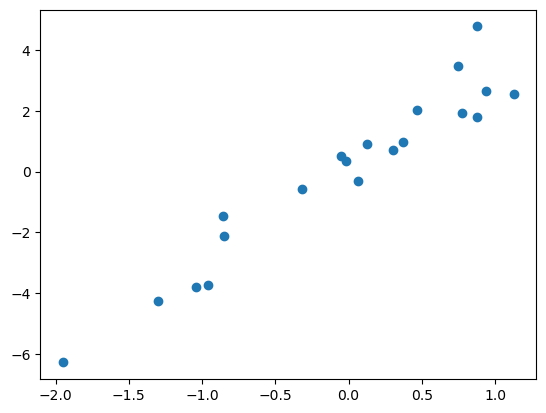

In [4]:
rng = np.random.default_rng(42)
X = rng.standard_normal(size=(20 , 1))
y = 3 * X + rng.standard_normal(size=(20 , 1))
plt.scatter(X, y);

In [5]:
coef = utils.fit_regression(X, y)
coef

array([[3.15525491]])

**Exercise**: The cell below samples 500 points from the same model. Use `utils.fit_regression` and print the estimated $\beta$ coefficient. Is this value close to the true value $\beta=3$?

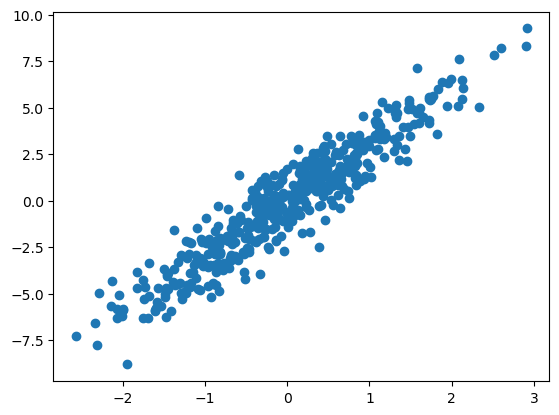

In [6]:
rng = np.random.default_rng(42)
X = rng.standard_normal(size=(500 , 1))
y = 3 * X + rng.standard_normal(size=(500, 1))
plt.scatter(X, y);

In [7]:
coef = utils.fit_regression(X, y)
coef

array([[2.99134185]])

**Exercise**: The cell below samples 100 data points from a different model. Use `utils.fit_regression` to estimate the value of $\beta$.

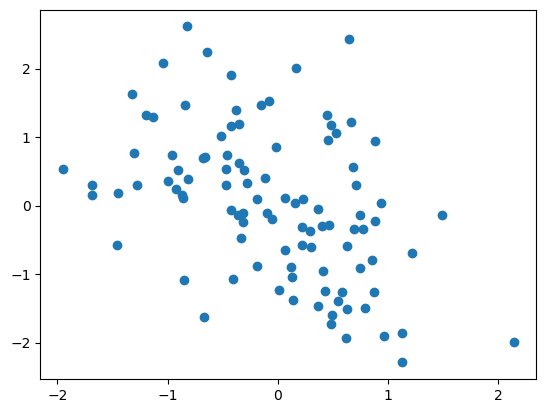

In [8]:
rng = np.random.default_rng(42)
X = rng.standard_normal(size=(100 , 1))
y = -0.75 * X + rng.standard_normal(size=(100, 1))
plt.scatter(X, y);

In [9]:
coef = utils.fit_regression(X, y)
coef

array([[-0.63043635]])

**Example**: Estimate the value of $\beta$ and use `utils.apply_regression` to compute the predicted values for y `y_pred`. Plot the original data points together with the prediction.

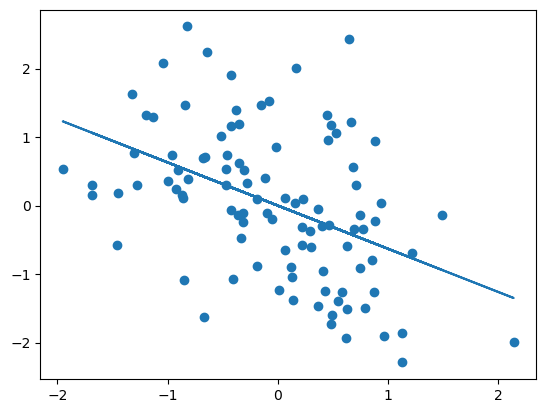

In [10]:
coef = utils.fit_regression(X, y)
y_pred = utils.apply_regression(X, coef)
plt.scatter(X, y)
plt.plot(X, y_pred);

**Exercise**: The cell below samples 100 data points from the model $y = 2 + 3x$. Estimate the value of $\beta$ and use `utils.apply_regression` to compute the predicted values for y `y_pred`. Plot the original data points together with the prediction. Does the line fit the data?

In [11]:
rng = np.random.default_rng(42)
X = rng.standard_normal(size=(100 , 1))
y = 2 + 3 * X + rng.standard_normal(size=(100,1))

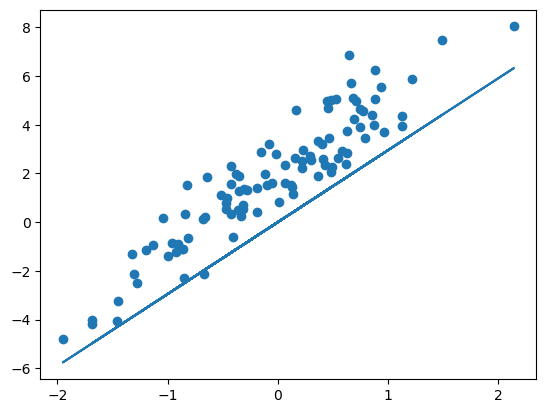

In [12]:
coef = utils.fit_regression(X, y)
y_pred = utils.apply_regression(X, coef)
plt.scatter(X, y)
plt.plot(X, y_pred);

**Exercise**: Repeat the code from above but set `intercept=True` when calling `utils.fit_regression()` to also estimate the intercept $\alpha$. Does the line fit the data now?

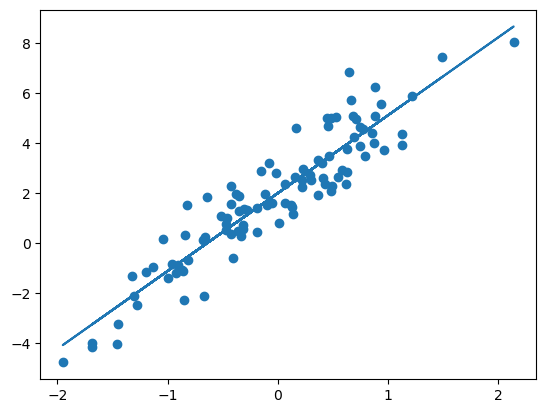

In [13]:
coef = utils.fit_regression(X, y, intercept=True)
y_pred = utils.apply_regression(X, coef)
plt.scatter(X, y)
plt.plot(X, y_pred);

**Exercise**: Print the estimated coefficients from the previous exercise. Do they match the true values $\alpha=2$ and $\beta=3$?

In [14]:
coef

array([[1.99535902],
       [3.11917464]])

**Exercise**: The cell below samples 100 data points from the model $y = 2 + 3x_1 - 1.5x_2 + 0.8x_3$. Use `utils.fit_regression()` to fit a linear regression with intercept and print the estimated coefficients.

In [15]:
rng = np.random.default_rng(42)
X = rng.standard_normal(size=(100 , 3))
y = 2 + 3*X[:,0] - 1.5*X[:,1] + 0.8*X[:,2] + rng.standard_normal(100)

In [16]:
coef = utils.fit_regression(X, y, intercept=True)
coef

array([ 2.08767734,  3.00559502, -1.43020719,  0.60250069])

**Example**: Predict the relationship between $y$ and $x_1$ (`X[:,0]`) using the estimates for $\alpha$ and $\beta_1$ (`coef[[0, 1]]`) and plot the original data together with the estimated relationship.

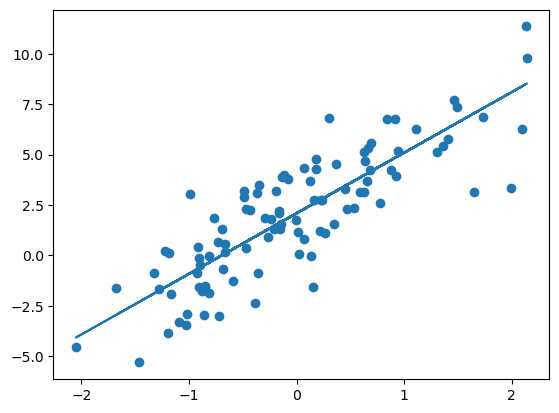

In [17]:
y_pred = utils.apply_regression(X[:,0], coef[[0, 1]])
plt.scatter(X[:,0], y)
plt.plot(X[:,0], y_pred)


**Exercise**: Predict the relationship between $y$ and $x_2$ (`X[:,1]`) using the estimates for $\alpha$ and $\beta_2$ (`coef[[0, 2]]`) and plot the original data together with the estimated relationship.

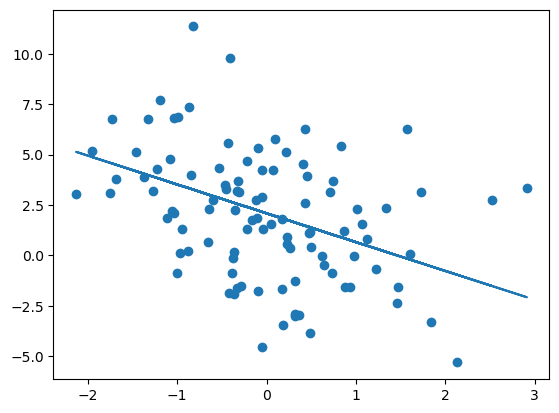

In [18]:
y_pred = utils.apply_regression(X[:,1], coef[[0, 2]])
plt.scatter(X[:,1], y)
plt.plot(X[:,1], y_pred)

**Exercise**: Predict the relationship between $y$ and $x_3$ (`X[:,2]`) using the estimates for $\alpha$ and $\beta_3$ (`coef[[0, 3]]`) and plot the original data together with the estimated relationship.

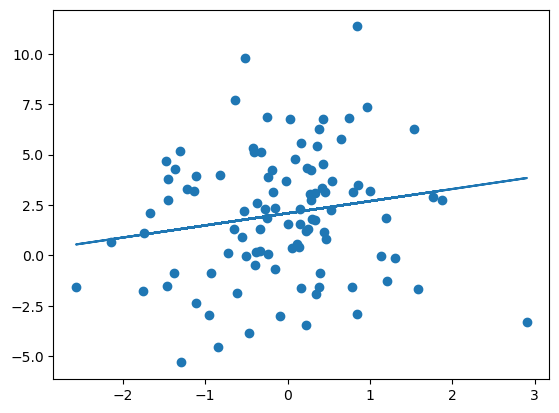

In [19]:
y_pred = utils.apply_regression(X[:,2], coef[[0, 3]])
plt.scatter(X[:,2], y)
plt.plot(X[:,2], y_pred)

## Making Robust Predictions with Ridge Regularization

### Background

OLS finds the coefficients that best fit the training data, but when the number of predictors is large relative to the number of observations, it can **overfit** — fitting the noise in the training data rather than the underlying signal. As a result, the model performs well on the training data but poorly on new, unseen data.

Ridge regression addresses this by adding a penalty on the size of the coefficients to the OLS objective:

$$\hat{\beta} = \underset{\beta}{\arg\min} \|y - X\beta\|^2 + \lambda\|\beta\|^2$$

This shrinks the coefficients toward zero, reducing overfitting. The strength of the regularization is controlled by $\lambda$: a larger $\lambda$ leads to more shrinkage. The solution is:

$$(X^T X + \lambda I)\hat{\beta} = X^T y$$

When $\lambda$ is 0, ridge regression is equivalent to OLS.

### Exercises

In this section, you'll use the `lam` parameter in `utils.fit_regression` to use ridge regression with different values of $\lambda$. You'll fit ridge regression to training data and evaluate it on test data to see how well the model generalizes to new, unseen data. To evaluate model accuracy, you are going to use the mean squared error (MSE) between the observed data and the model's predictions. Here are the relevant code snippets:

| Code | Description |
| --- | --- |
| `utils.fit_regression(X, y, lam=1)` | Fit ridge regression with regularization strength $\lambda=1$ |
| `np.sqrt(np.mean((y - y_pred)**2))` | Compute the root mean squared error (RMSE) between `y` and `y_pred` |
| `np.linspace(0, 10, 20)` | Create an array of 20 evenly spaced values between `0` and `10` |
| `np.argmin(arr)` | Return the index of the smallest value in `arr` |

The cell below generates 30 samples with 10 predictors, only two of which are actually associated with y (in reality we usually do not know which predictors are associated with y).

 We then assign the first 15 samples to the train set and the rest to the test set. We'll fit the regression on the train set and evaluate it on the test set to see how well the model generalizes to unseen data.

In [20]:
rng = np.random.default_rng(42)
X = rng.standard_normal(size=(30 , 10))
y = 1 + 1.75*X[:,0] - 0.9*X[:,1] + rng.standard_normal(30)

X_train, X_test = X[:15], X[15:]
y_train, y_test = y[:15], y[15:]

**Example**: Fit OLS regression on the train set, predict `y_train` and compute the root mean squared error (RMSE) of the prediction: `np.sqrt(np.mean((y_train-y_train_pred)**2))`.

In [21]:
coef = utils.fit_regression(X_train, y_train, intercept=True)
y_train_pred = utils.apply_regression(X_train, coef)
np.sqrt(np.mean((y_train-y_train_pred)**2))

np.float64(0.34449221293568083)

**Exercise**: Use the `coef` from above to predict the test set and compute the MSE. How does it compare to the MSE for the train set?

In [22]:
y_test_pred = utils.apply_regression(X_test, coef)
np.sqrt(np.mean((y_test-y_test_pred)**2))

np.float64(2.339959720309392)

**Exercise**: Fit a regression to the train set again but set `lam=5` to use ridge regression with $\lambda=5$. Predict `y_train` and compute the MSE. How does it compare to the previous MSE for the train set?

In [23]:
coef = utils.fit_regression(X_train, y_train, intercept=True, lam=5)
y_train_pred = utils.apply_regression(X_train, coef)
np.sqrt(np.mean((y_train-y_train_pred)**2))

np.float64(0.7331380443164357)

**Exercise**: Use the `coef` from above to predict the test set and compute the MSE. How does it compare to the previous MSE for the test set?

In [24]:
y_test_pred = utils.apply_regression(X_test, coef)
np.sqrt(np.mean((y_test-y_test_pred)**2))

np.float64(1.54951283002279)

**Exercise**: Fit a ridge regression on the train set with $\lambda=15$ and use the estimated coefficients to predict `y_train` and `y_test`. How do the MSEs for test and train set compare to the previous exercises?

In [25]:
coef = utils.fit_regression(X_train, y_train, intercept=True, lam=15)
y_train_pred = utils.apply_regression(X_train, coef)
y_test_pred = utils.apply_regression(X_test, coef)
np.sqrt(np.mean((y_train-y_train_pred)**2)), np.sqrt(np.mean((y_test-y_test_pred)**2))

(np.float64(1.0963781800130035), np.float64(1.479133147713668))

**Exercise**: Fit a ridge regression on the train set with $\lambda=1000$ and use the estimated coefficients to predict `y_train` and `y_test`. Is the MSE larger for the train or test set?

In [26]:
coef = utils.fit_regression(X_train, y_train, intercept=True, lam=1000)
y_train_pred = utils.apply_regression(X_train, coef)
y_test_pred = utils.apply_regression(X_test, coef)
np.sqrt(np.mean((y_train-y_train_pred)**2)), np.sqrt(np.mean((y_test-y_test_pred)**2))

(np.float64(1.757910624020377), np.float64(1.733375772618923))

**Exercise**: Use `np.linspace()` to create an array with 20 `lambdas` between `0` and `100` and run the cell below to compute the MSE on the test set for every $\lambda$ and plot the result.

In [27]:
lambdas = ... # np.linspace()

In [28]:
lambdas = np.linspace(0, 100, 20)

<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\l'
C:\Users\olebi\AppData\Local\Temp\ipykernel_6016\301864113.py:8: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel("$\lambda$")


Text(0, 0.5, 'MSE (Train Set)')

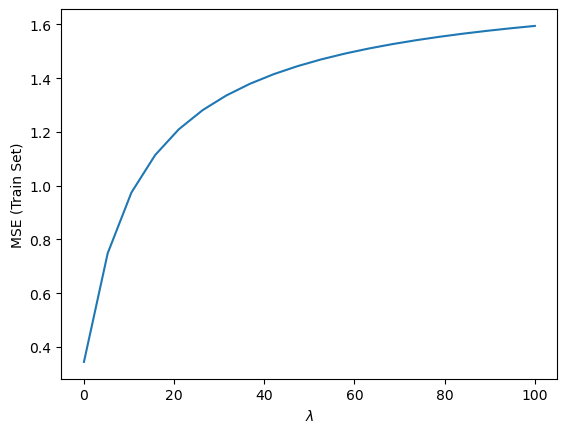

In [29]:
mse = []
for lam in lambdas:
    coef = utils.fit_regression(X_train, y_train, intercept=True, lam=lam)
    y_train_pred = utils.apply_regression(X_train, coef)
    mse.append(np.sqrt(np.mean((y_train-y_train_pred)**2)))

plt.plot(lambdas, mse)
plt.xlabel("$\lambda$")
plt.ylabel("MSE (Train Set)")

**Exercise**: Use `np.linspace()` to create an array with 1000 `lambdas` between `0` and `200` and run the cell below to compute the MSE on the test set for every $\lambda$ and plot the result.

In [30]:
lambdas = ... # np.linspace()

In [31]:
lambdas = np.linspace(0, 200, 1000)

<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\l'
C:\Users\olebi\AppData\Local\Temp\ipykernel_6016\1128564933.py:8: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel("$\lambda$")


Text(0, 0.5, 'MSE (Test Set)')

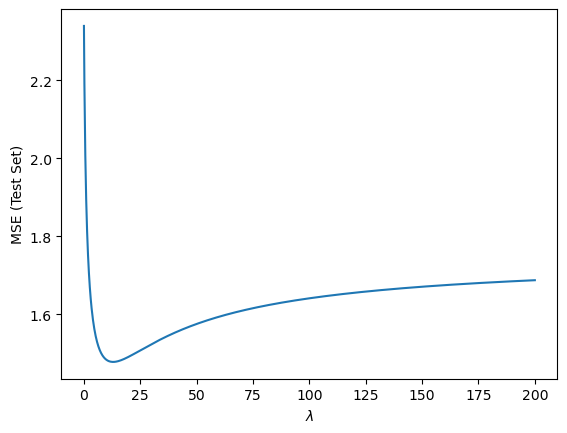

In [32]:
mse = []
for lam in lambdas:
    coef = utils.fit_regression(X_train, y_train, intercept=True, lam=lam)
    y_test_pred = utils.apply_regression(X_test, coef)
    mse.append(np.sqrt(np.mean((y_test-y_test_pred)**2)))

plt.plot(lambdas, mse)
plt.xlabel("$\lambda$")
plt.ylabel("MSE (Test Set)")

**Exercise**: Use `np.argmin` to find the index of the smallest MSE for the test set and run the cell below to print the optimal value for $\lambda$.

In [33]:
min_idx = ... # np.argmin()

In [34]:
min_idx = np.argmin(mse)

In [35]:
print("Optimal value for lambda: ", lambdas[min_idx])

Optimal value for lambda:  13.013013013013014


## Quantifying Uncertainty with Bootstrapping

### Background

In the previous section we used ridge regression and found the value of $\lambda$ for making predictions on new, unseen data. However, a single regression fit gives point estimates of the coefficients, but not a measure of how reliable those estimates are. **Bootstrapping** is a resampling technique that quantifies this uncertainty without requiring distributional assumptions.

The idea is simple: repeatedly resample the data with replacement, refit the model on each resample, and collect the resulting coefficients. The spread of these bootstrapped estimates reflects how much the coefficients would vary if the experiment were repeated — giving a confidence interval (CI) for each coefficient.

A coefficient whose CI does not include zero can be considered statistically significant at the corresponding level.

### Exercises

In the following exercises you are going to apply bootstrap resampling to identify which coefficients are significantly associated with the dependent variable. You are also going to see how ridge and OLS regression differ with respect to the coefficient estimates. The notebook provides the resampling code as well as a utility function to visualize the estimates with confidence intervals:

| Code | Description |
| --- | --- |
| `idx = np.random.choice(n, n, replace=True)` | Draw `n` random indices with replacement (bootstrap resample) |
| `np.stack(arrays)` | Stack a list of arrays into a single array |
| `utils.plot_bootstrap_coefs(coefs)` | Plot mean coefficients with 95% CI, asterisk marks CIs excluding 0 |
| `utils.plot_bootstrap_coefs(coefs, ci=99)` | Plot with a 99% CI |

**Exercise**: The code below randomly samples from `X` and `y` and then applies ridge regression to the resulting bootstrap sample `X_boot`, `y_boot`. Rerun the cell a few times and observe how the values of the estimated coefficients change.

**Note**: The true trend in the data is given by the equation $y = 1 + 1.75 x_1 - 0.9 x_2$. $x_3$ to $x_{10}$ are not associated with $y$ at all.

In [36]:
idx = np.random.choice(len(X), len(X), replace=True)
X_boot, y_boot = X[idx], y[idx]
coef = utils.fit_regression(X_boot, y_boot, intercept=True, lam=13)
coef

array([ 1.3884586 ,  0.84237433, -0.51571247, -0.12048601,  0.08048033,
       -0.21857775, -0.2166483 ,  0.10664956, -0.04401173,  0.05101159,
       -0.13380468])

**Exercise**: Set `n_boot` to `100` and run the cell below to compute the regression coefficients 100 times with bootstrap resampling using the previously estimated best value of $\lambda=13$. Print the bootstrapped coefficients - what is the shape of the array?

In [37]:
n_boot = ...

In [38]:
n_boot = 100

In [39]:
coefs = []
for i in range(n_boot):
    idx = np.random.choice(len(X), len(X), replace=True)
    X_boot, y_boot = X[idx], y[idx]
    coef = utils.fit_regression(X_boot, y_boot, intercept=True, lam=13)
    coefs.append(coef)
coefs = np.stack(coefs)
coefs

array([[ 1.53274696,  0.93343334, -0.39716221, ...,  0.01654231,
        -0.04869085,  0.17535812],
       [ 1.30001236,  0.9656736 , -0.46377667, ..., -0.1633605 ,
         0.01817936, -0.08824285],
       [ 1.37831274,  1.0620297 , -0.6207596 , ...,  0.01893274,
        -0.09513076, -0.06181206],
       ...,
       [ 0.68807225,  0.839347  , -0.38684142, ..., -0.19070123,
        -0.0103681 , -0.05031597],
       [ 1.26267597,  0.60448468, -0.5968994 , ...,  0.03638993,
        -0.0878992 , -0.34455815],
       [ 1.4129096 ,  0.93645082, -0.32757715, ...,  0.00629118,
        -0.00416219,  0.0444275 ]], shape=(100, 11))

**Exercise**: Rerun the code from above but set `n_boot` to `10_000`. How did this change the shape of `coefs`?

In [40]:
n_boot = 10000
coefs = []
for i in range(n_boot):
    idx = np.random.choice(len(X), len(X), replace=True)
    X_boot, y_boot = X[idx], y[idx]
    coef = utils.fit_regression(X_boot, y_boot, intercept=True, lam=13)
    coefs.append(coef)
coefs = np.stack(coefs)
coefs

array([[ 1.16376123,  0.91932653, -0.52318636, ..., -0.04005805,
         0.00622894, -0.01055087],
       [ 0.71981098,  0.74720603, -0.61386525, ..., -0.21358839,
         0.04059264, -0.04168028],
       [ 0.60009823,  0.50618003, -0.35472565, ..., -0.02257663,
         0.24381197, -0.2083966 ],
       ...,
       [ 1.36402732,  1.09748579, -0.41739738, ..., -0.37825275,
        -0.05268722,  0.00897088],
       [ 1.21151147,  0.8651606 , -0.46148949, ..., -0.08589089,
        -0.08941054,  0.12469235],
       [ 1.32794852,  0.99902475, -0.26318018, ...,  0.0817952 ,
        -0.04312828,  0.21930798]], shape=(10000, 11))

**Example**: Plot the mean value for each coefficient across all bootstrap resamples with a 95% confidence interval (CI). The asterisk indicates that the CI for the given coefficient does not include 0.

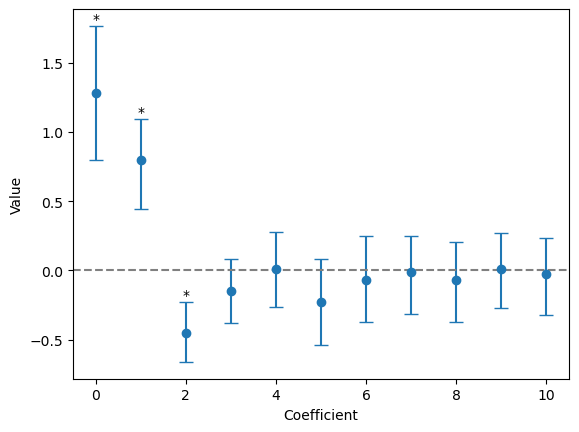

In [41]:
utils.plot_bootstrap_coefs(coefs, ci=95)

**Exercise**: Plot the bootstrapped coefficients with a 99% and 99.9% CI. Which coefficients are significantly different from 0?

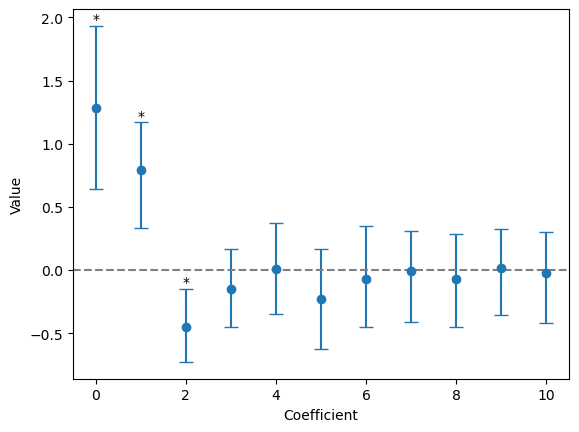

In [42]:
utils.plot_bootstrap_coefs(coefs, ci=99)

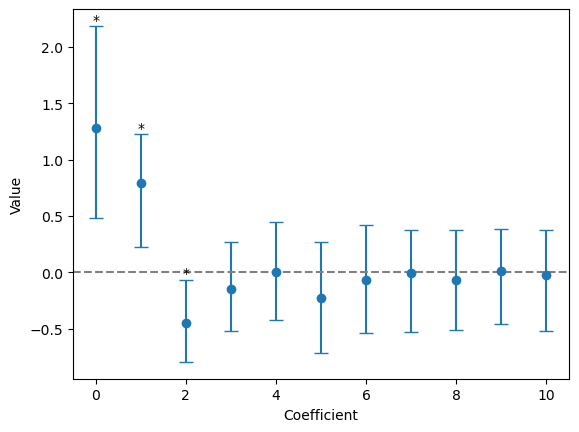

In [43]:
utils.plot_bootstrap_coefs(coefs, ci=99.9)

**Exercise**: Repeat the bootstrap estimation of the coefficients but set `lam=0` to use OLS regression. Plot the estimated coefficients with a 99.9% CI. How does this compare to the coefficients estimated with ridge regression?

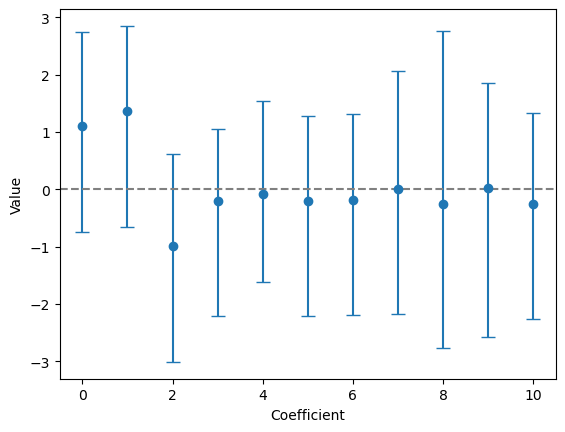

In [44]:
n_boot = 10000
coefs = []
for i in range(n_boot):
    idx = np.random.choice(len(X), len(X), replace=True)
    X_boot, y_boot = X[idx], y[idx]
    coef = utils.fit_regression(X_boot, y_boot, intercept=True, lam=0)
    coefs.append(coef)
coefs = np.stack(coefs)
utils.plot_bootstrap_coefs(coefs, ci=99.9)

## Implementing OLS and Ridge Regression in NumPy

### Background

In the previous sections we used the provided utility functions to fit and apply OLS and ridge regression. This allowed us to focus on the interpretation of the results rather than the implementation of the regression itself. However, the functions are actually pretty straightforward and can be implemented in a few steps using NumPy. This section will show you how to do exactly that.

### Exercises

In this section you are going to apply OLS and ridge regression to simulated data using only NumPy functions and the matrix multiplication operator `@`. Some of the steps will be provided for you and there will be hints in the exercise text on which functions to use.

| Code | Description |
| --- | --- |
| `np.ones((n, 1))` | Create an $n \times 1$ column of ones |
| `np.hstack((A, B))` | Horizontally stack arrays `A` and `B` |
| `np.eye(p)` | Create a $p \times p$ identity matrix |
| `np.linalg.solve(A, b)` | Solve the linear system $Ax = b$ for $x$ |
| `X.T @ X` | Compute $X^TX$ |
| `X @ coef` | Compute predictions $\hat{y} = X\hat{\beta}$ |

The cell below generates 100 data points from the model $y = 1 + 2x$.

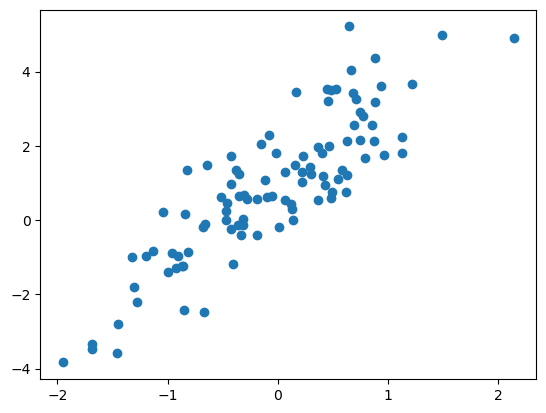

In [45]:
rng = np.random.default_rng(42)
X = rng.standard_normal(size=(100, 1))
y = 1 + 2 * X + rng.standard_normal(size=(100, 1))
plt.scatter(X, y)

**Exercise**: Solve the normal equations $(X^TX)\beta = X^Ty$ using `np.linalg.solve(X.T @ X, X.T @ y)` and print the returned regression coefficients.

In [46]:
coef = np.linalg.solve(X.T @ X, X.T @ y)
coef

array([[2.03574216]])

**Exercise**: Predict the values of $y$ via matrix multiplication of `X` and the estimated coefficients (`X @ coef`). Then plot the original data together with the prediction.

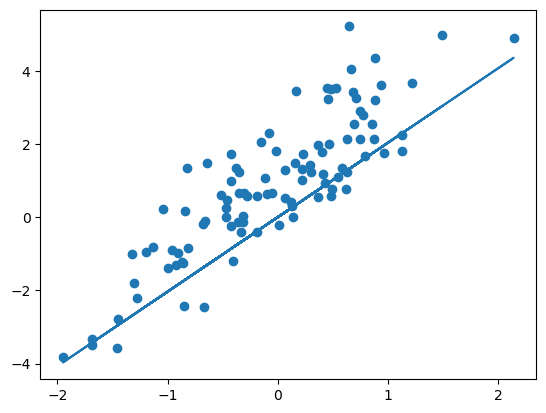

In [47]:
y_pred = X @ coef
plt.scatter(X, y)
plt.plot(X, y_pred)

**Example**: To fit an intercept, we prepend a column of `np.ones()` to `X`. The coefficient assigned to that column gets multiplied by 1 for every sample and thus acts as a constant offset.

In [48]:
X = np.hstack((np.ones((len(X), 1)), X))
X[:10]

array([[ 1.        ,  0.30471708],
       [ 1.        , -1.03998411],
       [ 1.        ,  0.7504512 ],
       [ 1.        ,  0.94056472],
       [ 1.        , -1.95103519],
       [ 1.        , -1.30217951],
       [ 1.        ,  0.1278404 ],
       [ 1.        , -0.31624259],
       [ 1.        , -0.01680116],
       [ 1.        , -0.85304393]])

**Exercise**: Solve the normal equations $(X^TX)\beta = X^Ty$ using `np.linalg.solve(X.T @ X, X.T @ y)` and print the returned regression coefficients. Do the values match the true intercept $\alpha=1$ and slope $\beta=2$?

In [49]:
coef = np.linalg.solve(X.T @ X, X.T @ y)
coef

array([[0.99535902],
       [2.11917464]])

**Exercise**: Predict the values of $y$ via matrix multiplication of `X` and the estimated coefficients (`X @ coef`). Then plot the original data together with the prediction.

**Note**: Because we added a column of ones to `X`, use the second column when plotting (`X[:,1]`).

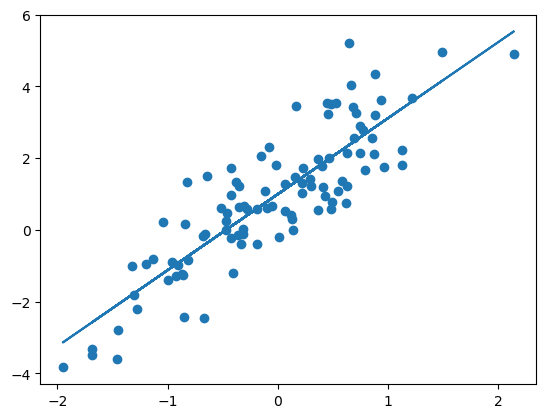

In [50]:
plt.scatter(X[:, 1], y)
plt.plot(X[:, 1], X @ coef)


**Example**: To use ridge regression, we create an identity matrix with the size equal to the number of features in `X`. We multiply it by $\lambda$ to control the regularization strength. Because we do not want to regularize the intercept, we set the first entry of `I` to 0.

In [51]:
I = np.eye(X.shape[1])
I[0, 0] = 0
I

array([[0., 0.],
       [0., 1.]])

**Exercise**: Solve the normal equations $(X^TX + \lambda I)\beta = X^Ty$ using `np.linalg.solve(X.T @ X + lam * I, X.T @ y)` with `lam=1`. Compute predictions and plot the original data together with the regression line.

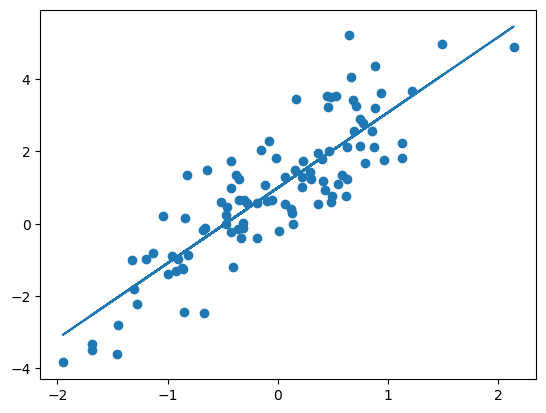

In [52]:
lam = 1
coef = np.linalg.solve(X.T @ X + lam * I, X.T @ y)
plt.scatter(X[:, 1], y)
plt.plot(X[:, 1], X @ coef)

**Exercise**: Test different values of $\lambda$ and observe how the slope of the regression changes.

<>:4: SyntaxWarning: invalid escape sequence '\l'
<>:4: SyntaxWarning: invalid escape sequence '\l'
C:\Users\olebi\AppData\Local\Temp\ipykernel_6016\2984694692.py:4: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(X[:, 1], X @ coef, label=f"$\lambda$={lam}")


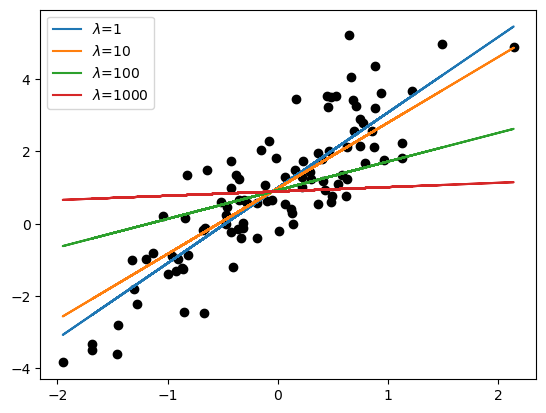

In [53]:
plt.scatter(X[:, 1], y, color="black")
for lam in [1, 10, 100, 1000]:
    coef = np.linalg.solve(X.T @ X + lam * I, X.T @ y)
    plt.plot(X[:, 1], X @ coef, label=f"$\lambda$={lam}")
plt.legend()